## PV shadow analysis for Bank 2 (West, 260°).

Two separate shadow matrices (North 6+2, South 4+2) are loaded and
analysed independently. Each sub-array gets its own SiteConfig with
the correct nominal power share. The final power output is the sum
of both sub-arrays, which is compared against the Bank 2 inverter
channel (MPP2).

Bank 2 specifications:
  - Orientation: 260° (West)
  - Inclination: 20°
  - 14 panels total, 4620 W nominal
  - North (6+2 = 8 panels): 8/14 × 4620 = 2640 W
  - South (4+2 = 6 panels): 6/14 × 4620 = 1980 W

Roof geometry (annotated aerial image):
  BANK 1 — SE-facing (main_analysis.py)
    Azimuth: 170°   Tilt: 12°   Panels: 12   Nominal: 3 960 W
    Inverter channel: MPP1
    Panels: 1-1…1-12

  BANK 2 — West-facing (this script)
    Azimuth: 260°   Tilt: 20°   Panels: 14   Nominal: 4 620 W
    Inverter channel: MPP2

    Part 1 — North sub-array (8 panels)
      Layout: (6, 2) left-aligned
      Anchor corner: (532882.93, 6983518.73) — panel 2-1-1 at (532884.50, 6983518.50)
      Row 0: 2-1-1  2-1-2  2-1-3  2-1-4  2-1-5  2-1-6
      Row 1: 2-1-7  2-1-8

    Part 2 — South sub-array (6 panels)
      Layout: (4, 2) right-aligned
      Anchor corner: (532888.63, 6983503.79) — panel 2-2-1 at (532889.50, 6983507.50)
      Row 0: 2-2-1  2-2-2  2-2-3  2-2-4
      Row 1: 2-2-5  2-2-6

Two separate shadow matrices are loaded and analysed independently.
Each sub-array gets its own SiteConfig with the correct nominal power
share. The final power output is the sum of both sub-arrays, compared
against the Bank 2 inverter channel (MPP2).

In [1]:
# %% --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MANUSCRIPT_FIG_DIR = Path("/Users/hdong/Projects/VoxSolaris_Article/figs")
MANUSCRIPT_FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
})


from pv_analysis_b2 import (
    SiteConfig,
    find_clear_days,
    load_and_smooth_shadow_matrix,
    load_extra_data_csv,
    load_inverter_data,
    pv_analysis,
    compute_metrics,
    print_performance_summary,
    plot_real_vs_predicted_scatter,
    save_all_day_plots,
)

from shadow_matrix_simulation_b2 import create_shadow_matrices

try:
    from visual_utils import plot_shadow_matrix_with_sunpaths, plot_shadow_polar_b2
except ImportError:
    plot_shadow_matrix_with_sunpaths = None
    plot_shadow_polar_b2 = None

import tqdm

In [2]:
# %% --- Configuration: Bank 2 (West, 260°, 14 panels, MPP2) ---
# Panel counts
N_NORTH = 8   # Part 1: panels 2-1-1 … 2-1-8
N_SOUTH = 6   # Part 2: panels 2-2-1 … 2-2-6
N_TOTAL = 14
NOMINAL_TOTAL_W = 4620.0

cfg_north = SiteConfig(
    latitude=62.979849,
    longitude=27.648656,
    tilt_deg=20.0,
    azimuth_deg=260.0,
    nominal_power_kw=NOMINAL_TOTAL_W * N_NORTH / N_TOTAL / 1000,  # 2.64 kW
    system_efficiency=0.85,
    local_tz="Europe/Helsinki",
    inverter_utc_offset_hours=3,
    window_size=(2, 2),
    interval="5min",
    interval_minutes=5.0,
    forecast_shift_minutes=-30,
)

cfg_south = SiteConfig(
    latitude=62.979849,
    longitude=27.648656,
    tilt_deg=20.0,
    azimuth_deg=260.0,
    nominal_power_kw=NOMINAL_TOTAL_W * N_SOUTH / N_TOTAL / 1000,  # 1.98 kW
    system_efficiency=0.85,
    local_tz="Europe/Helsinki",
    inverter_utc_offset_hours=3,
    window_size=(2, 2),
    interval="5min",
    interval_minutes=5.0,
    forecast_shift_minutes=-30,
)

# Combined cfg for metrics display / full-bank scatter plots
cfg_combined = SiteConfig(
    latitude=62.979849,
    longitude=27.648656,
    tilt_deg=20.0,
    azimuth_deg=260.0,
    nominal_power_kw=NOMINAL_TOTAL_W / 1000,  # 4.62 kW
    system_efficiency=0.85,
    local_tz="Europe/Helsinki",
    inverter_utc_offset_hours=3,
    window_size=(2, 2),
    interval="5min",
    interval_minutes=5.0,
    forecast_shift_minutes=-30,
)


# --- File Paths ---
RAD_FILE       = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_rad.csv"
TEMP_WIND_FILE = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_temp_wind.csv"
CLEAR_MINUTES  = "data/Clear_sky_minutes_kuopio_RH16.txt"
PV_EXCEL       = "data/pvdata/pv_21.xlsx"

LIDAR_FILE     = "output/reclassified_final_v5.laz"
SHADOW_DIR     = "results/shadow_matrix_results_W_pro"
SHADOW_NORTH   = f"{SHADOW_DIR}/shadow_attenuation_matrix_conecasting_W_north_v3.csv"
SHADOW_SOUTH   = f"{SHADOW_DIR}/shadow_attenuation_matrix_conecasting_W_south_v3.csv"
EXTRA_DATA_DIR = "output"

In [3]:
# %% --- 1. Find Clear Days ---
clear_days = find_clear_days(CLEAR_MINUTES, threshold=1.05)
print(f"Found {len(clear_days)} clear days")
print(clear_days.head())

Found 10 clear days (threshold: Q3 + 1.05 * IQR = 735.438 minutes, mode=line_count)
Found 10 clear days
          Date  LineCount  ClearMinutes
72  2021-07-03        914           914
73  2021-07-04        872           872
50  2021-06-09        821           821
52  2021-06-11        801           801
30  2021-05-13        796           796


In [4]:
# %% --- Reviewer TODO: 03_Site_Data.tex §Clear-Sky Day Selection (Bank 2) ---
# Re-rank clear days using fraction of clear minutes within daylight hours.
# Uses cfg_combined coordinates (same lat/lon as Bank 1).
#
# TODO[author]: Compare result with the Bank 1 comparison. If the set changes,
#   update selected days and metrics in the manuscript.

clear_days_fraction = find_clear_days(
    CLEAR_MINUTES,
    threshold=0.85, # Adjust threshold for fraction mode (e.g., 85% clear)
    ranking_mode="daylight_fraction",
    latitude=cfg_combined.latitude,
    longitude=cfg_combined.longitude,
    timestamp_tz="UTC",
    daylight_altitude_deg=0.0,
)

lc_dates = set(str(d) for d in clear_days["Date"])
fr_dates = set(str(d) for d in clear_days_fraction["Date"])

print("\n" + "=" * 55)
print("  CLEAR-SKY DAY SELECTION — COMPARISON (Bank 2)")
print("=" * 55)
print(f"  Line-count mode  ({len(lc_dates):2d} days): {sorted(lc_dates)}")
print(f"  Fraction mode    ({len(fr_dates):2d} days): {sorted(fr_dates)}")

added = fr_dates - lc_dates
removed = lc_dates - fr_dates
if not added and not removed:
    print("\n  >>> SAME SET: both modes select identical days.")
else:
    print(f"\n  >>> SET CHANGED: +{len(added)} new | -{len(removed)} removed")
    if added:
        print(f"      Added:   {sorted(added)}")
    if removed:
        print(f"      Removed: {sorted(removed)}")
    print("  >>> TODO[author]: Decide whether to use 'fraction' ranking.")

frac_cols = [c for c in ["Date", "ClearMinutes", "DaylightMinutes", "ClearFraction"]
             if c in clear_days_fraction.columns]
if frac_cols:
    print("\n  Daylight-fraction ranking (top 12 rows):")
    print(clear_days_fraction[frac_cols].head(12).to_string(index=False))


Found 10 clear days (threshold: Q3 + 0.85 * IQR = 0.689 fraction, mode=daylight_fraction)

  CLEAR-SKY DAY SELECTION — COMPARISON (Bank 2)
  Line-count mode  (10 days): ['2021-05-12', '2021-05-13', '2021-06-04', '2021-06-09', '2021-06-10', '2021-06-11', '2021-07-03', '2021-07-04', '2021-07-14', '2021-07-26']
  Fraction mode    (10 days): ['2021-04-16', '2021-04-17', '2021-04-19', '2021-05-12', '2021-05-13', '2021-06-09', '2021-07-03', '2021-07-04', '2021-07-26', '2021-09-27']

  >>> SET CHANGED: +4 new | -4 removed
      Added:   ['2021-04-16', '2021-04-17', '2021-04-19', '2021-09-27']
      Removed: ['2021-06-04', '2021-06-10', '2021-06-11', '2021-07-14']
  >>> TODO[author]: Decide whether to use 'fraction' ranking.

  Daylight-fraction ranking (top 12 rows):
      Date  ClearMinutes  DaylightMinutes  ClearFraction
2021-04-17           710            903.0       0.786268
2021-04-19           716            916.0       0.781659
2021-04-16           692            897.0       0.771460
2

In [5]:
import pvlib

def replace_dni_with_computed(df_extra, latitude, longitude):
    """
    Replace CAMS DNI with DNI computed from GHI, DHI, and solar zenith.
    Uses pvlib closure: DNI = (GHI - DHI) / cos(zenith)
    """
    solpos = pvlib.solarposition.get_solarposition(
        df_extra.index, latitude, longitude
    )
    zenith = solpos["apparent_zenith"]

    dni_computed = pvlib.irradiance.dni(
        ghi=df_extra["ghi"],
        dhi=df_extra["dhi"],
        zenith=zenith,
        # clearsky_dni=None,       # no clearsky limit
        # clearsky_tolerance=1.1,
    )

    df_extra["dni_cams"] = df_extra["dni"].copy()  # keep original
    df_extra["dni"] = dni_computed.clip(lower=0)

    return df_extra

In [6]:
# %% --- 2. Load Extra Data for First Clear Day ---
second_day = clear_days["Date"].iloc[1]  # Use second clear day
extra_data_df = load_extra_data_csv(
    f"{EXTRA_DATA_DIR}/extra_data_{second_day}.csv", cfg=cfg_combined
)
extra_data_df = replace_dni_with_computed(extra_data_df, cfg_combined.latitude, cfg_combined.longitude)
print(extra_data_df.head())

                           dni   dhi   ghi      T  wind  albedo  dni_cams
time                                                                     
2021-07-04 00:00:00+00:00  NaN  0.00 -0.36  18.10  0.72     0.2       0.0
2021-07-04 00:05:00+00:00 -0.0  0.02  0.02  18.08  0.96     0.2       0.0
2021-07-04 00:10:00+00:00  NaN  0.60  0.30  18.36  1.48     0.2       0.0
2021-07-04 00:15:00+00:00  NaN  1.68  0.48  19.12  1.82     0.2       0.0
2021-07-04 00:20:00+00:00  NaN  2.14  1.22  19.20  1.16     0.2       0.0


In [7]:
# %% --- 3. Generate Shadow Matrices (run once) ---
# Uncomment to generate:
_ = create_shadow_matrices(
    lidar_file_path=LIDAR_FILE,
    voxel_size=2.0,
    output_dir=SHADOW_DIR,
    skip_dist=1.0,
    offset_from_roof=-1.5,
    file_name_suffix="v3"
)

Loading LiDAR data from output/reclassified_final_v5.laz...
  2,327,728 points after filtering.
  Voxel grid: 250×250×29 = 1,812,500 voxels

  --- Sub-array: North (6, 2) — left-aligned ---
    Panels: 2-1-1…2-1-6 (row 0), 2-1-7…2-1-8 (row 1)
    Roof: 190 pts, max_z=97.13m, offset=-1.5m → panel_z=95.63m
    8 panel points

  --- Sub-array: South (4, 2) — right-aligned ---
    Panels: 2-2-1…2-2-4 (row 0), 2-2-5…2-2-6 (row 1)
    Roof: 3 pts, max_z=96.87m, offset=-1.5m → panel_z=95.37m
    6 panel points

  Self-occlusion skip distance: 1.0m (voxel_size=2.0m)

--- JIT warm-up (first trace) ---


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



--- Sweep: North (6+2) (8 panels) ---
  Elevation   9.0° done  (3,600/32,760 = 11.0%)  [1s elapsed]
  Elevation  19.0° done  (7,200/32,760 = 22.0%)  [1s elapsed]
  Elevation  29.0° done  (10,800/32,760 = 33.0%)  [2s elapsed]
  Elevation  39.0° done  (14,400/32,760 = 44.0%)  [2s elapsed]
  Elevation  49.0° done  (18,000/32,760 = 54.9%)  [3s elapsed]
  Elevation  59.0° done  (21,600/32,760 = 65.9%)  [3s elapsed]
  Elevation  69.0° done  (25,200/32,760 = 76.9%)  [4s elapsed]
  Elevation  79.0° done  (28,800/32,760 = 87.9%)  [4s elapsed]
  Elevation  89.0° done  (32,400/32,760 = 98.9%)  [5s elapsed]
  Elevation  90.0° done  (32,760/32,760 = 100.0%)  [5s elapsed]
  North (6+2) completed in 4.7s

--- Sweep: South (4+2) (6 panels) ---
  Elevation   9.0° done  (3,600/32,760 = 11.0%)  [0s elapsed]
  Elevation  19.0° done  (7,200/32,760 = 22.0%)  [1s elapsed]
  Elevation  29.0° done  (10,800/32,760 = 33.0%)  [1s elapsed]
  Elevation  39.0° done  (14,400/32,760 = 44.0%)  [2s elapsed]
  Elevation

In [8]:
# %% --- 4. Load Shadow Matrices ---
shadow_north = load_and_smooth_shadow_matrix(SHADOW_NORTH, window_size=cfg_north.window_size)
shadow_south = load_and_smooth_shadow_matrix(SHADOW_SOUTH, window_size=cfg_south.window_size)
print(f"Shadow matrices loaded — North: {shadow_north.shape}, South: {shadow_south.shape}")

Shadow matrices loaded — North: (91, 361), South: (91, 361)


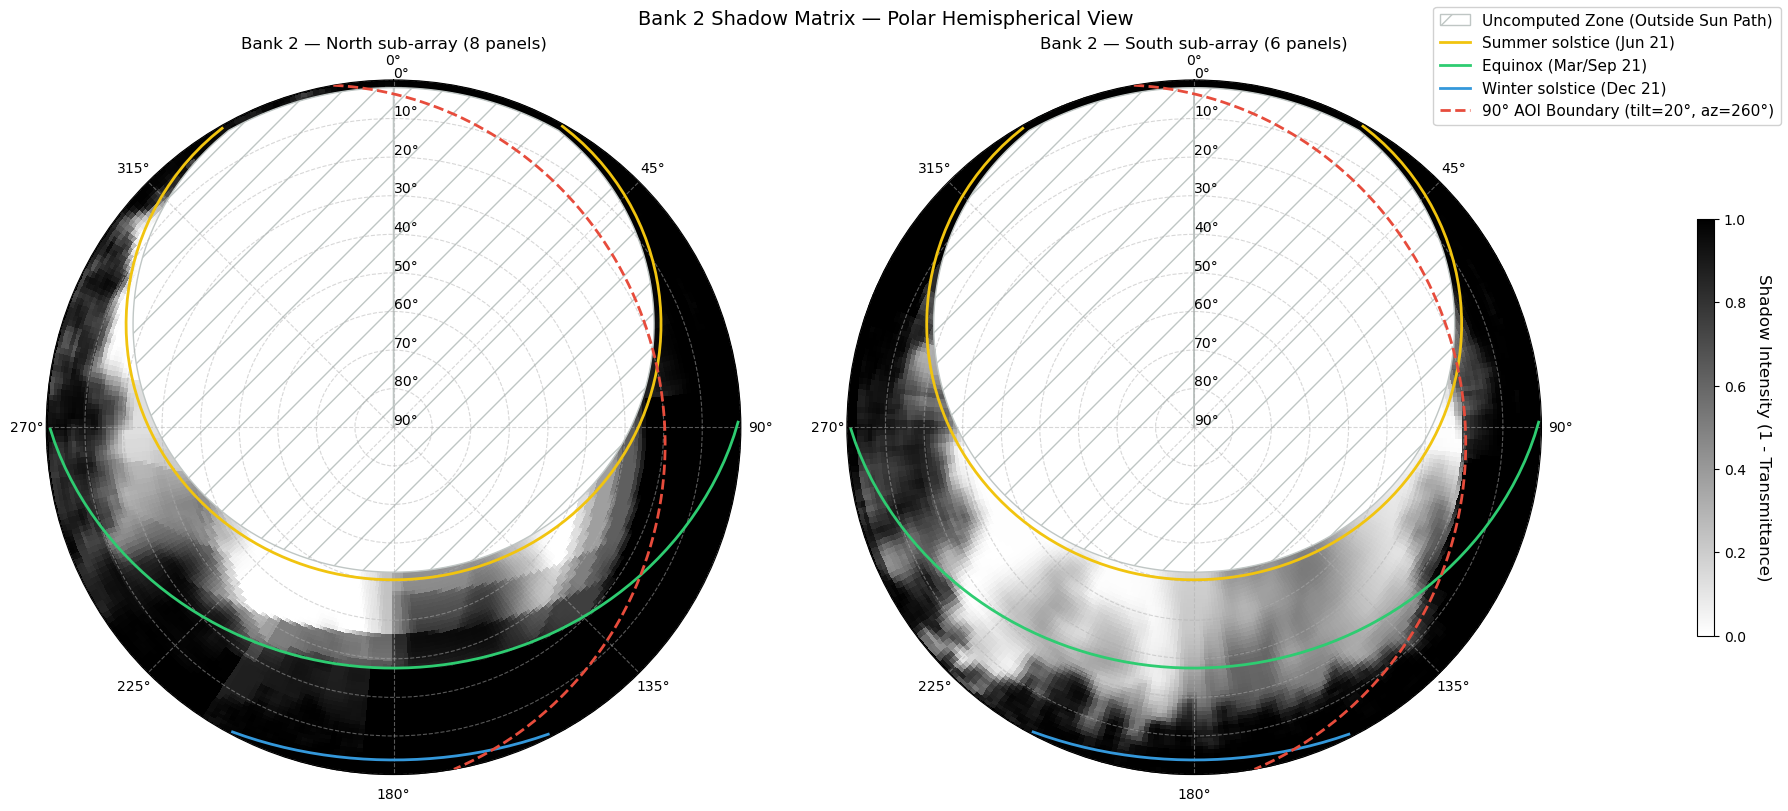

In [9]:
# %% --- 5. Visualise Shadow Matrices ---

if plot_shadow_polar_b2 is not None:
    plot_shadow_polar_b2(
        SHADOW_NORTH,
        SHADOW_SOUTH,
        save_path=str(MANUSCRIPT_FIG_DIR / "SAM_bank2.png"),
        show=True,
        dpi=300,
    )


In [10]:
# %% --- 6. Load Inverter Data (Bank 2 = MPP2) ---
pv_df = load_inverter_data(
    PV_EXCEL,
    expected_interval_min=cfg_combined.interval_minutes,
    energy_column="MPP2",
)
print(f"Loaded {len(pv_df)} inverter records (Bank 2 / MPP2).")

  Energy column: 'Energia MPP2 | Symo 8.2-3-M (1)' (index 3)
Inverter data: 102,263 records, 102235/102262 normal intervals, 27 gaps
  Largest gaps: [965. 925. 905. 875. 825.] min
Loaded 102263 inverter records (Bank 2 / MPP2).


In [11]:
# %% --- 7. Combined PV Analysis for a Single Day ---
def pv_analysis_bank2(
    target_date, shadow_north, shadow_south,
    excel_df, df_extra, plot=True, save_path=None,
):
    """
    Run PV analysis for Bank 2 by analysing North and South sub-arrays
    separately, then summing their outputs.

    Returns
    -------
    day_data : DataFrame with real power (full Bank 2)
    fb_combined : DataFrame with base forecast (no shadows)
    fw_combined : DataFrame with shadow-corrected forecast
    """
    # North sub-array
    day_n, fb_n, fw_n = pv_analysis(
        target_date, shadow_north, excel_df, df_extra,
        cfg=cfg_north, plot=False,
    )
    # South sub-array
    day_s, fb_s, fw_s = pv_analysis(
        target_date, shadow_south, excel_df, df_extra,
        cfg=cfg_south, plot=False,
    )

    # Real power is the full Bank 2 measurement (not split)
    day_data = day_n.copy()  # same inverter data for both

    # Combined forecast = sum of sub-arrays
    fb_combined = fb_n.copy()
    fb_combined["output"] = fb_n["output"] + fb_s["output"]

    fw_combined = fw_n.copy()
    fw_combined["output_shaded"] = fw_n["output_shaded"] + fw_s["output_shaded"]

    if plot:
        import matplotlib.dates as mdates
        fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

        full_idx = day_data.index

        # --- Top: Combined ---
        ax = axes[0]
        ax.plot(full_idx, day_data["Power_W"],
                label="Real Power (Bank 2)", color="#2ecc71", lw=1.5)
        ax.plot(full_idx, fb_combined["output"],
                label="Base Forecast (N+S)", color="#3498db", ls="--", lw=1.6)
        ax.plot(full_idx, fw_combined["output_shaded"],
                label="Shadow-Corrected (N+S)", color="#e67e22", lw=1.6)
        ax.set_title(f"Bank 2 Combined — {target_date}", fontsize=13)
        ax.set_ylabel("Power (W)", fontsize=12)
        ax.legend(loc="upper right", fontsize=10)
        ax.grid(True, alpha=0.3)

        # --- Middle: North sub-array ---
        ax = axes[1]
        ax.plot(full_idx, fb_n["output"],
                label="Base (North 6+2)", color="#3498db", ls="--")
        ax.plot(full_idx, fw_n["output_shaded"],
                label="Shaded (North 6+2)", color="#e67e22")
        ax.set_title("North Sub-array (6+2, 8 panels)", fontsize=12)
        ax.set_ylabel("Power (W)", fontsize=12)
        ax.legend(loc="upper right", fontsize=10)
        ax.grid(True, alpha=0.3)

        # --- Bottom: South sub-array ---
        ax = axes[2]
        ax.plot(full_idx, fb_s["output"],
                label="Base (South 4+2)", color="#3498db", ls="--")
        ax.plot(full_idx, fw_s["output_shaded"],
                label="Shaded (South 4+2)", color="#e67e22")
        ax.set_title("South Sub-array (4+2, 6 panels)", fontsize=12)
        ax.set_ylabel("Power (W)", fontsize=12)
        ax.set_xlabel("Time (Local)", fontsize=12)
        ax.legend(loc="upper right", fontsize=10)
        ax.grid(True, alpha=0.3)

        for a in axes:
            a.xaxis.set_major_locator(mdates.HourLocator(interval=1))
            a.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            a.set_xlim(full_idx[0], full_idx[-1])
            a.tick_params(axis="both", labelsize=10)

        plt.tight_layout()
        plt.show()

    return day_data, fb_combined, fw_combined

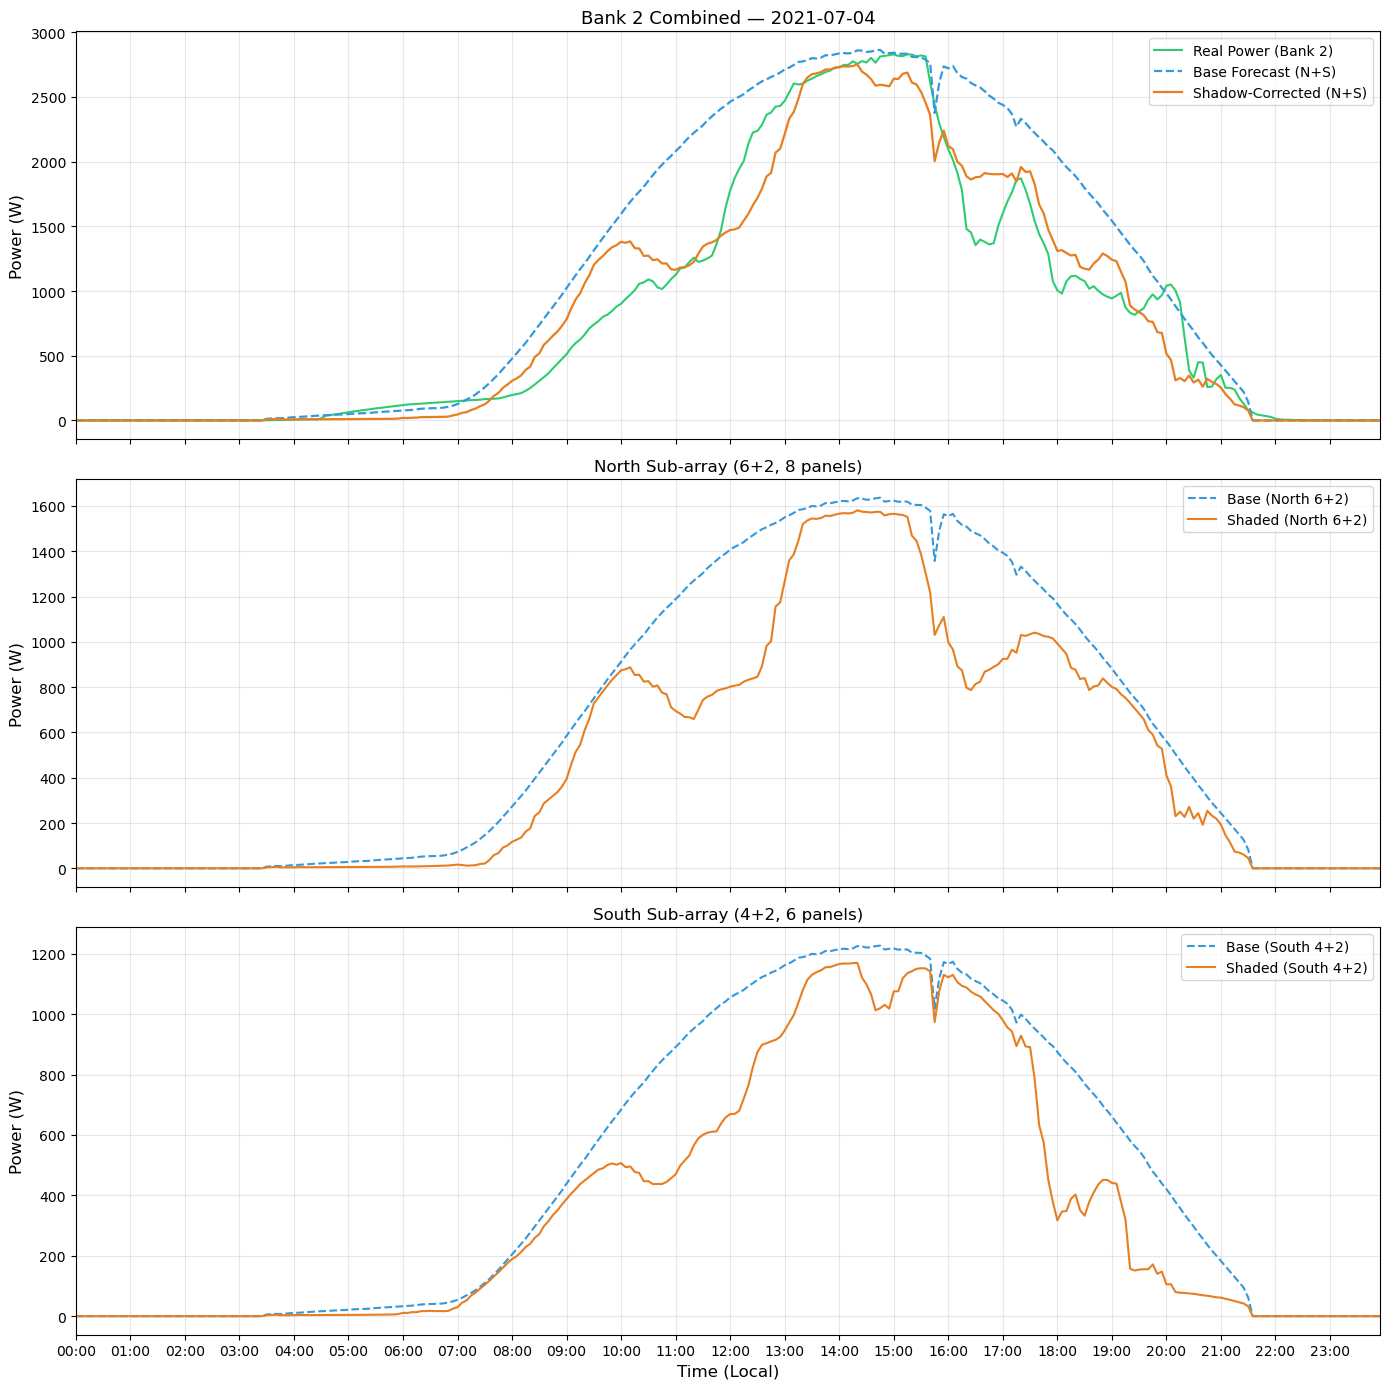

In [12]:
# Single-day test
day_data, forecast_base, forecast_windowed = pv_analysis_bank2(
    second_day, shadow_north, shadow_south,
    pv_df, extra_data_df, plot=True,
    save_path=str(MANUSCRIPT_FIG_DIR / "b2_july04_timeseries.png"),
)

In [13]:
# %% --- 8. Single-Day Metrics ---
metrics = compute_metrics(
    day_data, forecast_base, forecast_windowed, cfg_combined.interval_minutes
)
print(f"\nMetrics for {second_day} (Bank 2 combined):")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k:15s}: {v:10.2f}")


Metrics for 2021-07-04 (Bank 2 combined):
  RMSE_Base      :     522.83
  RMSE_Shaded    :     245.65
  MAE_Base       :     385.68
  MAE_Shaded     :     187.75
  MBE_Base       :     370.57
  MBE_Shaded     :      16.87
  R2_Base        :       0.68
  R2_Shaded      :       0.93
  Real_Wh        :   19839.56
  Base_Wh        :   26355.35
  Shaded_Wh      :   20136.12


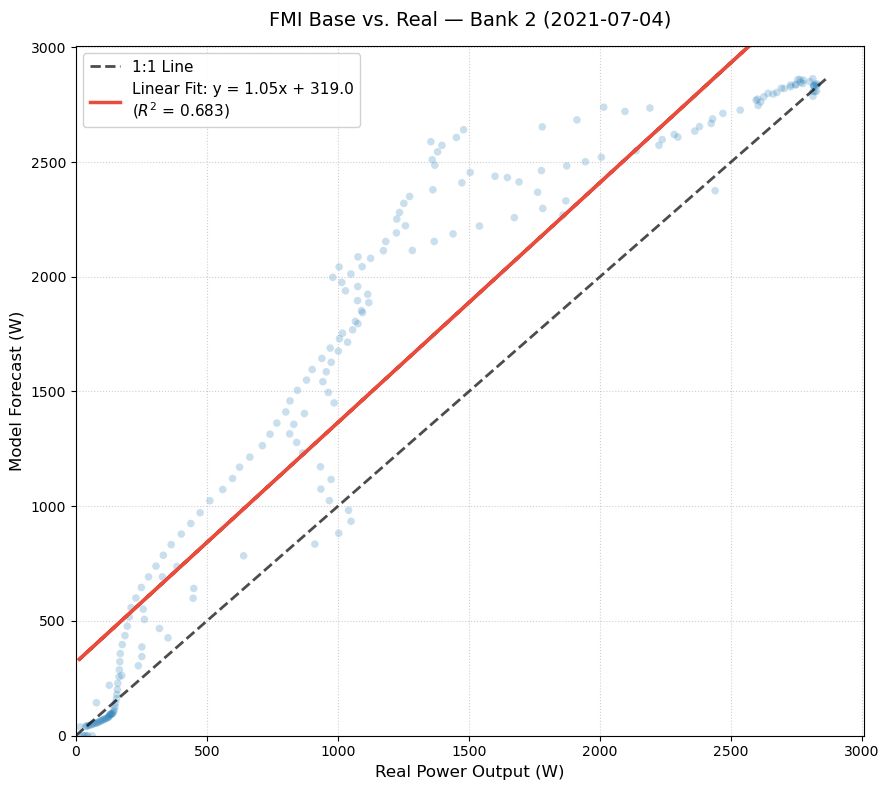

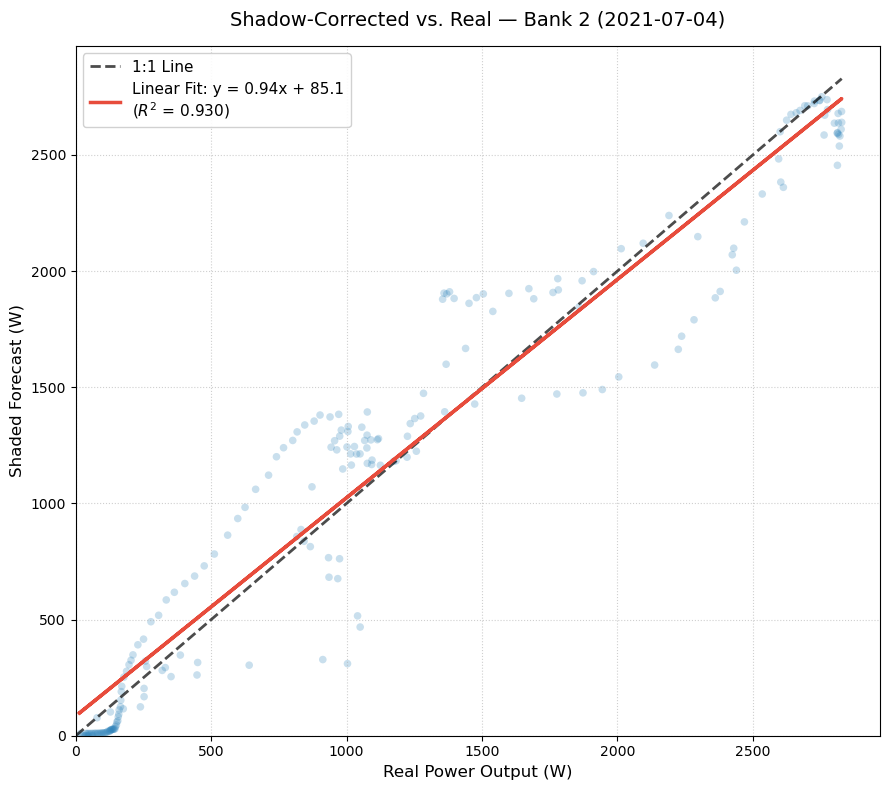

In [14]:
# %% --- 9. Scatter Plots for Single Day ---
plot_real_vs_predicted_scatter(
    day_data["Power_W"].values,
    forecast_base["output"].values,
    title=f"FMI Base vs. Real — Bank 2 ({second_day})",
    ylabel="Model Forecast (W)",
)

plot_real_vs_predicted_scatter(
    day_data["Power_W"].values,
    forecast_windowed["output_shaded"].values,
    title=f"Shadow-Corrected vs. Real — Bank 2 ({second_day})",
    ylabel="Shaded Forecast (W)",
)

                           dni   dhi   ghi      T  wind  albedo
time                                                           
2021-07-04 00:00:00+00:00  0.0  0.00 -0.36  18.10  0.72     0.2
2021-07-04 00:05:00+00:00  0.0  0.02  0.02  18.08  0.96     0.2
2021-07-04 00:10:00+00:00  0.0  0.60  0.30  18.36  1.48     0.2
2021-07-04 00:15:00+00:00  0.0  1.68  0.48  19.12  1.82     0.2
2021-07-04 00:20:00+00:00  0.0  2.14  1.22  19.20  1.16     0.2


Evaluating Bank 2: 100%|██████████| 10/10 [00:00<00:00, 18.11it/s]


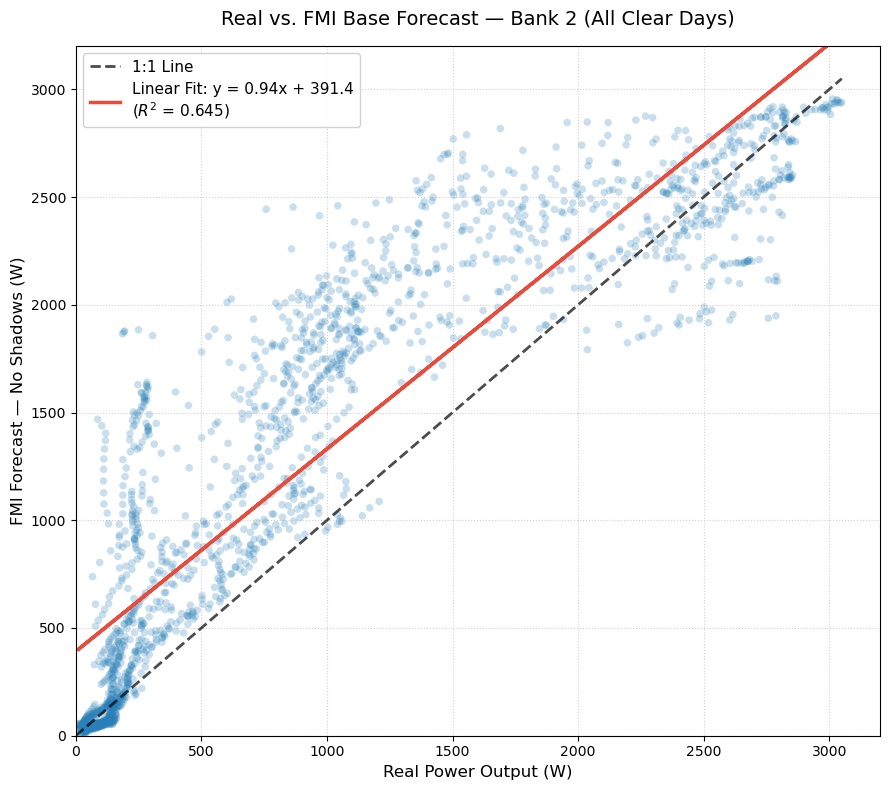

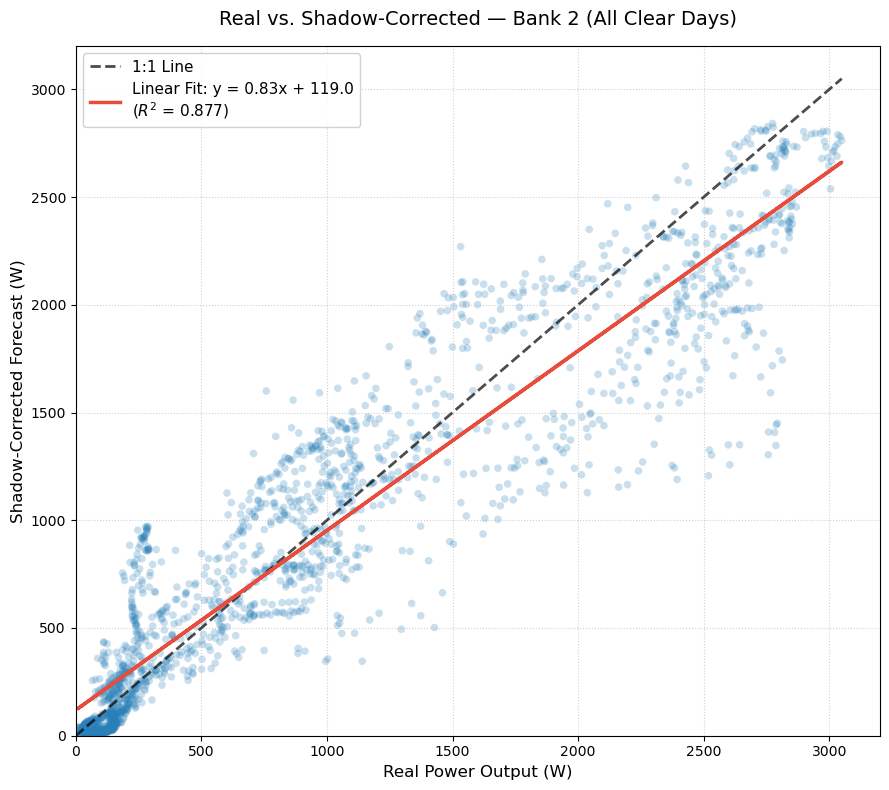


  PV FORECAST PERFORMANCE METRICS (CLEAR DAYS)

  RMSE  Base:     544.25 W
  RMSE  Shaded:   315.89 W  (+42.0%)

  MAE   Base:     397.22 W
  MAE   Shaded:   225.73 W  (+43.2%)

  MBE   Base:    +339.91 W
  MBE   Shaded:   -44.93 W

  R2    Base:      0.645
  R2    Shaded:    0.877

  --- Energy Yield ---
  Real:      149.39 kWh
  Base:      200.61 kWh  (+34.3%)
  Shaded:    142.86 kWh  (-4.4%)


In [15]:
# %% --- 10. Multi-Day Batch Evaluation ---
# def _load_cached_extra(date_obj):
#     try:
#         return load_extra_data_csv(
#             f"{EXTRA_DATA_DIR}/extra_data_{date_obj}.csv", cfg=cfg_combined
#         )
#     except FileNotFoundError:
#         print(f"  Warning: No extra data for {date_obj}, skipping.")
#         return None

# %% --- Build extra_data from FMI CSVs ---
from build_extra_data import make_extra_data_loader

RAD_CSV = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_rad.csv"
TW_CSV  = "data/pvdata/Kuopio Savilahti 1.4.2021 - 1.10.2021_temp_wind.csv"
LAT, LON = 62.8924, 27.6353

extra_loader = make_extra_data_loader(
    rad_csv=RAD_CSV, temp_wind_csv=TW_CSV,
    latitude=LAT, longitude=LON,
)

# %% --- 2. Load Extra Data for First Clear Day (test) ---
second_day = clear_days["Date"].iloc[1]
extra_data_df = extra_loader(second_day)
print(extra_data_df.head())

# %% --- 10. Multi-Day Batch Evaluation ---
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

daily_stats = []
all_real = []
all_pred_shaded = []
all_pred_base = []

for date_obj in tqdm.tqdm(clear_days_fraction["Date"].tolist(), desc="Evaluating Bank 2"):
    df_extra = extra_loader(date_obj)
    if df_extra is None or df_extra.empty:
        continue

    dd, fb, fw = pv_analysis_bank2(
        date_obj, shadow_north, shadow_south,
        pv_df, df_extra, plot=False,
    )
    metrics = compute_metrics(dd, fb, fw, cfg_combined.interval_minutes)

    all_real.extend(dd["Power_W"].fillna(0.0).values)
    all_pred_shaded.extend(fw["output_shaded"].fillna(0.0).values)
    all_pred_base.extend(fb["output"].fillna(0.0).values)

    daily_stats.append({
        "Date": (date_obj.strftime("%Y-%m-%d")
                 if hasattr(date_obj, "strftime") else str(date_obj)),
        **metrics,
    })

results_df = pd.DataFrame(daily_stats)

if not results_df.empty:
    plot_real_vs_predicted_scatter(
        all_real, all_pred_base,
        title="Real vs. FMI Base Forecast — Bank 2 (All Clear Days)",
        ylabel="FMI Forecast — No Shadows (W)",
        save_path=str(MANUSCRIPT_FIG_DIR / "b2_clearsky_scatter_base.png"),
        )
    plot_real_vs_predicted_scatter(
        all_real, all_pred_shaded,
        title="Real vs. Shadow-Corrected — Bank 2 (All Clear Days)",
        ylabel="Shadow-Corrected Forecast (W)",
        save_path=str(MANUSCRIPT_FIG_DIR / "b2_clearsky_scatter_corr.png"),
        )

print_performance_summary(results_df, real_arr=all_real, base_arr=all_pred_base, shaded_arr=all_pred_shaded)

In [16]:
# %% --- 10b. Save All Daily Plots ---
# %% --- 10b. Save All Daily Plots ---
import os
import matplotlib.dates as mdates
def save_all_day_plots_bank2(output_dir="results/daily_plots_bank2"):
    os.makedirs(output_dir, exist_ok=True)
    saved = 0
    for date_obj in tqdm.tqdm(clear_days_fraction["Date"].tolist(), desc="Saving daily plots"):
        df_extra = extra_loader(date_obj)
        if df_extra is None or df_extra.empty:
            continue

        dd, fb, fw = pv_analysis_bank2(
            date_obj, shadow_north, shadow_south,
            pv_df, df_extra, plot=False,
        )
        date_str = (date_obj.strftime("%Y-%m-%d")
                    if hasattr(date_obj, "strftime") else str(date_obj))

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(dd.index, dd["Power_W"],
                label="Real Power (Bank 2)", color="#2ecc71", lw=1.5)
        ax.plot(fb.index, fb["output"],
                label="Base Forecast", color="#3498db", ls="--")
        ax.plot(fw.index, fw["output_shaded"],
                label="Shadow-Corrected", color="#e67e22")
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.set_xlim(dd.index[0], dd.index[-1])
        ax.set_title(f"Bank 2 (West) — PV Comparison: {date_str}", fontsize=13)
        ax.set_xlabel("Time (Local)", fontsize=12)
        ax.set_ylabel("Power (W)", fontsize=12)
        ax.legend(loc="upper right", fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="both", labelsize=10)
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f"bank2_{date_str}.png"),
                    dpi=200, bbox_inches="tight")
        plt.close(fig)
        saved += 1

    print(f"\nSaved {saved} daily plots to {output_dir}/")

save_all_day_plots_bank2(output_dir="results/daily_plots_10d_b2")

Saving daily plots: 100%|██████████| 10/10 [00:02<00:00,  4.50it/s]


Saved 10 daily plots to results/daily_plots_10d_b2/


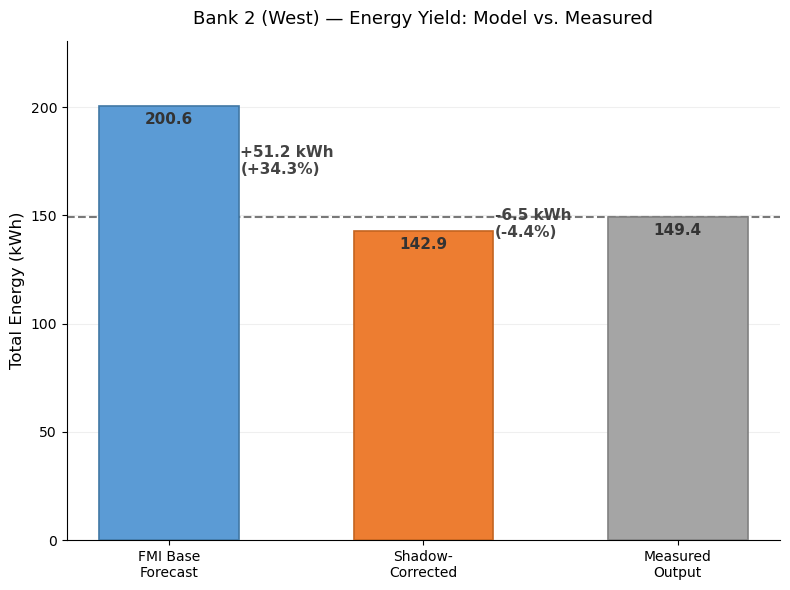

In [17]:
# %% --- 11. Energy Yield Bar Chart ---
def plot_energy_bar_chart(results_df, save_path=None):
    totals = results_df[["Real_Wh", "Base_Wh", "Shaded_Wh"]].sum() / 1000

    labels = ["FMI Base\nForecast", "Shadow-\nCorrected", "Measured\nOutput"]
    values = [totals["Base_Wh"], totals["Shaded_Wh"], totals["Real_Wh"]]
    target = values[2]

    fig, ax = plt.subplots(figsize=(8, 6))
    colors = ["#5B9BD5", "#ED7D31", "#A5A5A5"]
    edge_colors = ["#4178A4", "#C46420", "#808080"]
    bars = ax.bar(labels, values, color=colors, edgecolor=edge_colors,
                  width=0.55, linewidth=1.2, zorder=3)

    ax.axhline(y=target, color="#404040", ls="--", lw=1.5, alpha=0.7, zorder=2)
    # ax.text(2.35, target, f"{target:,.1f} kWh", va="center", fontsize=9,
    #         color="#404040", fontstyle="italic")

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h - max(values) * 0.015,
                f"{h:,.1f}", ha="center", va="top", fontsize=11,
                fontweight="bold", color="#333333")

    for i in range(2):
        err = values[i] - target
        cx = bars[i].get_x() + bars[i].get_width() / 2
        h = bars[i].get_height()
        sign = "+" if err >= 0 else ""
        err_pct = err / target * 100
        # ax.annotate("", xy=(cx, target), xytext=(cx, h),
        #             arrowprops=dict(arrowstyle="<->", color="#666666", lw=1.5), zorder=4)
        ax.text(cx + 0.28, (h + target) / 2,
                f"{sign}{err:.1f} kWh\n({sign}{err_pct:.1f}%)",
                fontsize=11, color="#444444", ha="left", va="center", fontweight="bold")

    ax.set_ylabel("Total Energy (kWh)", fontsize=12)
    ax.set_title("Bank 2 (West) — Energy Yield: Model vs. Measured", fontsize=13, pad=12)
    ax.set_ylim(0, max(values) * 1.15)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2, zorder=0)
    ax.tick_params(axis="both", labelsize=10)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()


if not results_df.empty:
    plot_energy_bar_chart(results_df, save_path=str(MANUSCRIPT_FIG_DIR / "b2_clearsky_energy.png"))


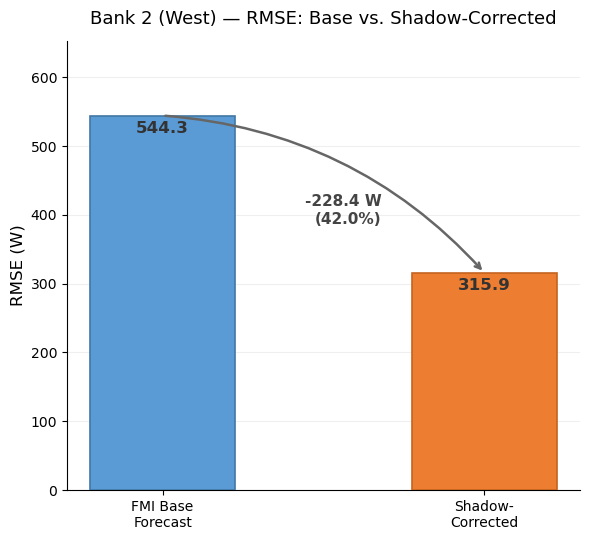

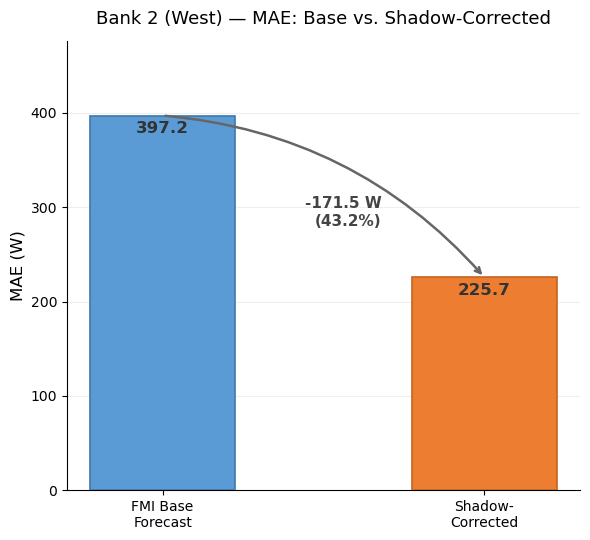

In [18]:
# %% --- 12. RMSE & MAE Bar Charts ---
def _plot_metric_comparison(base_val, shaded_val, metric_name, unit="W"):
    imp = base_val - shaded_val
    imp_pct = (imp / base_val) * 100 if base_val != 0 else 0

    labels = ["FMI Base\nForecast", "Shadow-\nCorrected"]
    values = [base_val, shaded_val]

    fig, ax = plt.subplots(figsize=(6, 5.5))
    colors = ["#5B9BD5", "#ED7D31"]
    edge_colors = ["#4178A4", "#C46420"]
    bars = ax.bar(labels, values, color=colors, edgecolor=edge_colors,
                  width=0.45, linewidth=1.2, zorder=3)

    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h - max(values) * 0.015,
                f"{h:,.1f}", ha="center", va="top", fontsize=12,
                fontweight="bold", color="#333333")

    cx0 = bars[0].get_x() + bars[0].get_width() / 2
    cx1 = bars[1].get_x() + bars[1].get_width() / 2
    mid_x = (cx0 + cx1) / 2
    mid_y = (values[0] + values[1]) / 2

    ax.annotate("", xy=(cx1, values[1]), xytext=(cx0, values[0]),
                arrowprops=dict(arrowstyle="->", color="#666666", lw=1.8,
                                connectionstyle="arc3,rad=-0.2"), zorder=4)
    ax.text(mid_x + 0.18, mid_y, f"-{imp:.1f} {unit}\n({imp_pct:.1f}%)",
            fontsize=11, color="#444444", ha="right", va="top", fontweight="bold")

    ax.set_ylabel(f"{metric_name} ({unit})", fontsize=12)
    ax.set_title(f"Bank 2 (West) — {metric_name}: Base vs. Shadow-Corrected",
                 fontsize=13, pad=12)
    ax.set_ylim(0, max(values) * 1.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.2, zorder=0)
    ax.tick_params(axis="both", labelsize=10)
    plt.tight_layout()
    plt.show()


if not results_df.empty:
    _plot_metric_comparison(
        results_df["RMSE_Base"].mean(),
        results_df["RMSE_Shaded"].mean(),
        "RMSE", "W",
    )
    _plot_metric_comparison(
        results_df["MAE_Base"].mean(),
        results_df["MAE_Shaded"].mean(),
        "MAE", "W",
    )

Saved: results/plots_b2/slope_b2.png


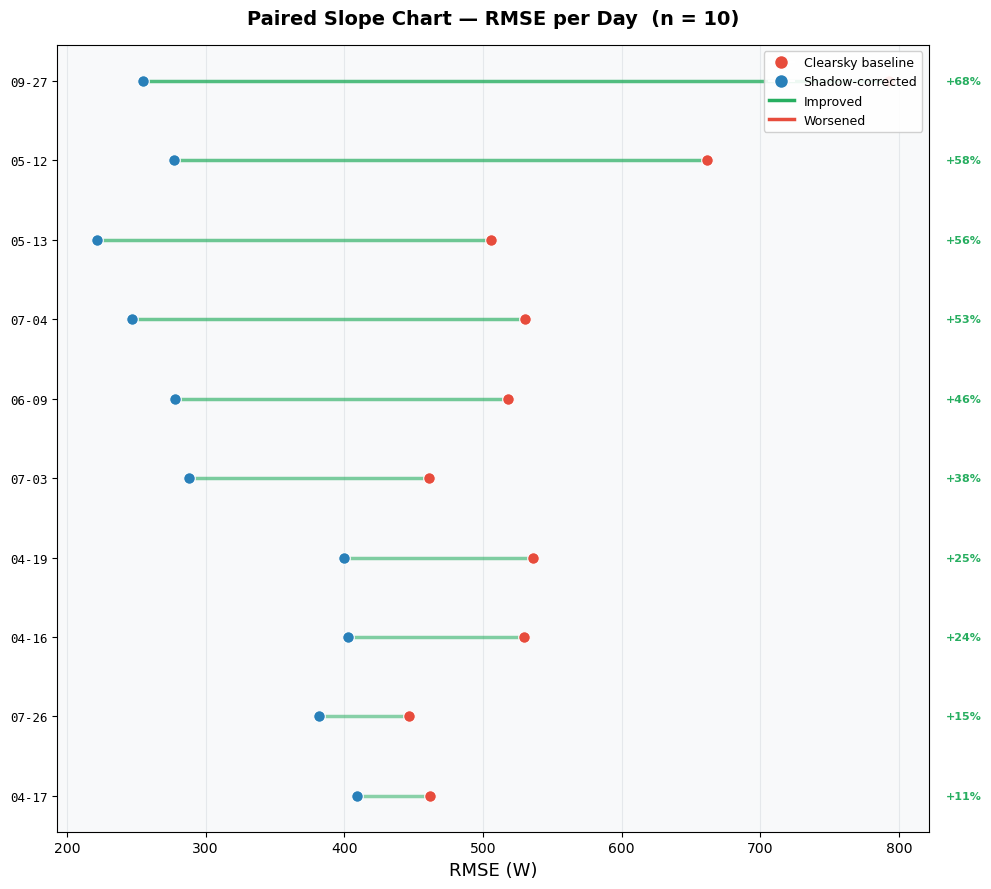

Saved: /Users/hdong/Projects/VoxSolaris_Article/figs/b2_clearsky_ridgeline.png


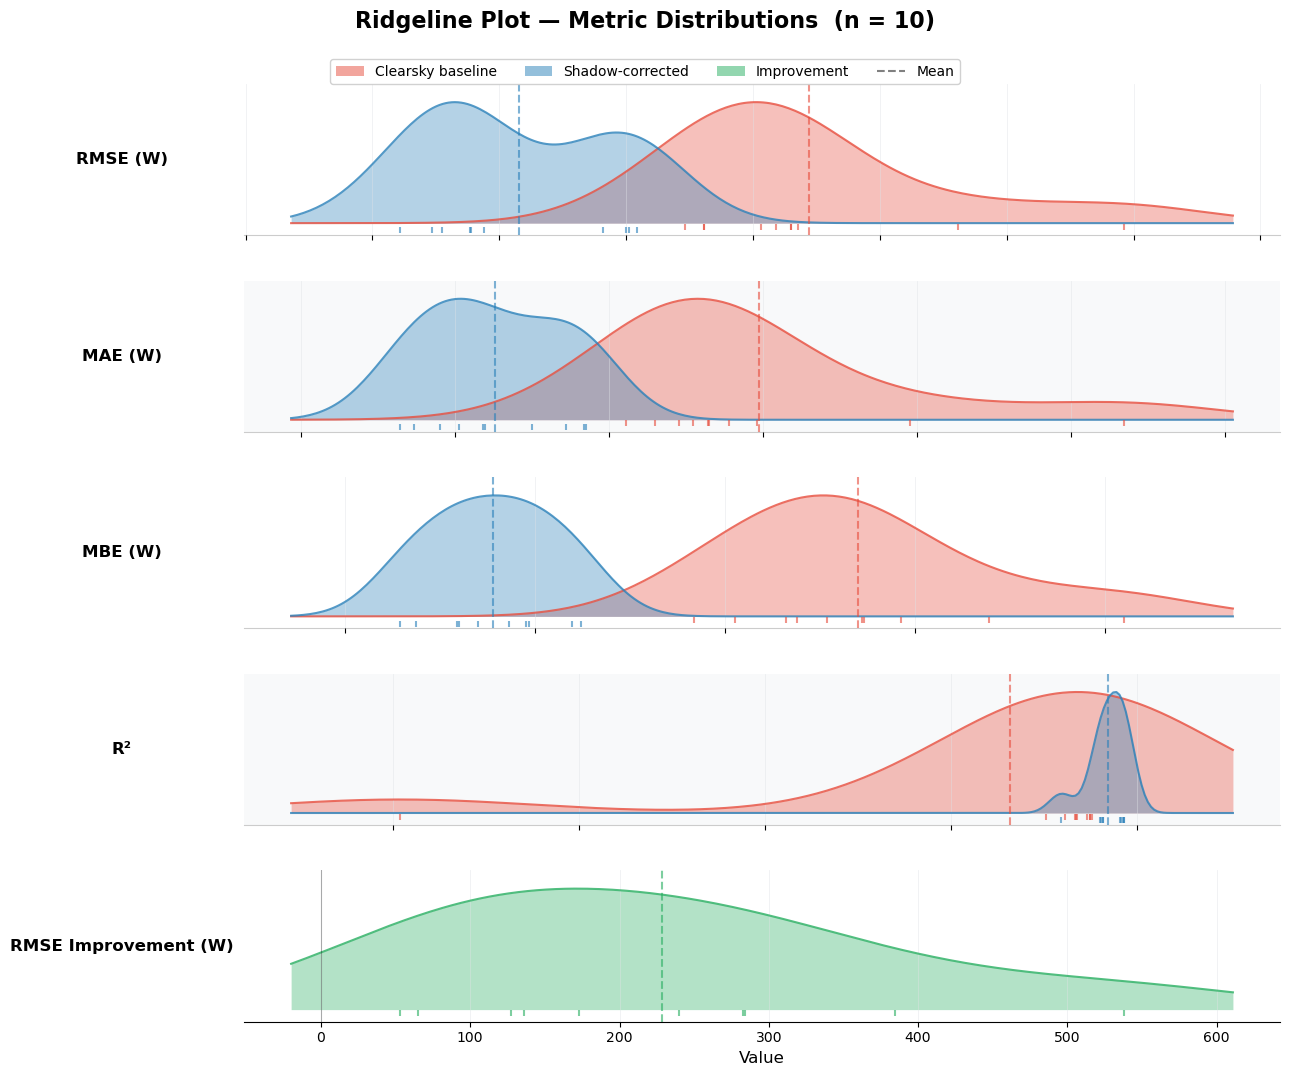

Saved: results/plots_b2/energy_slope_b2.png


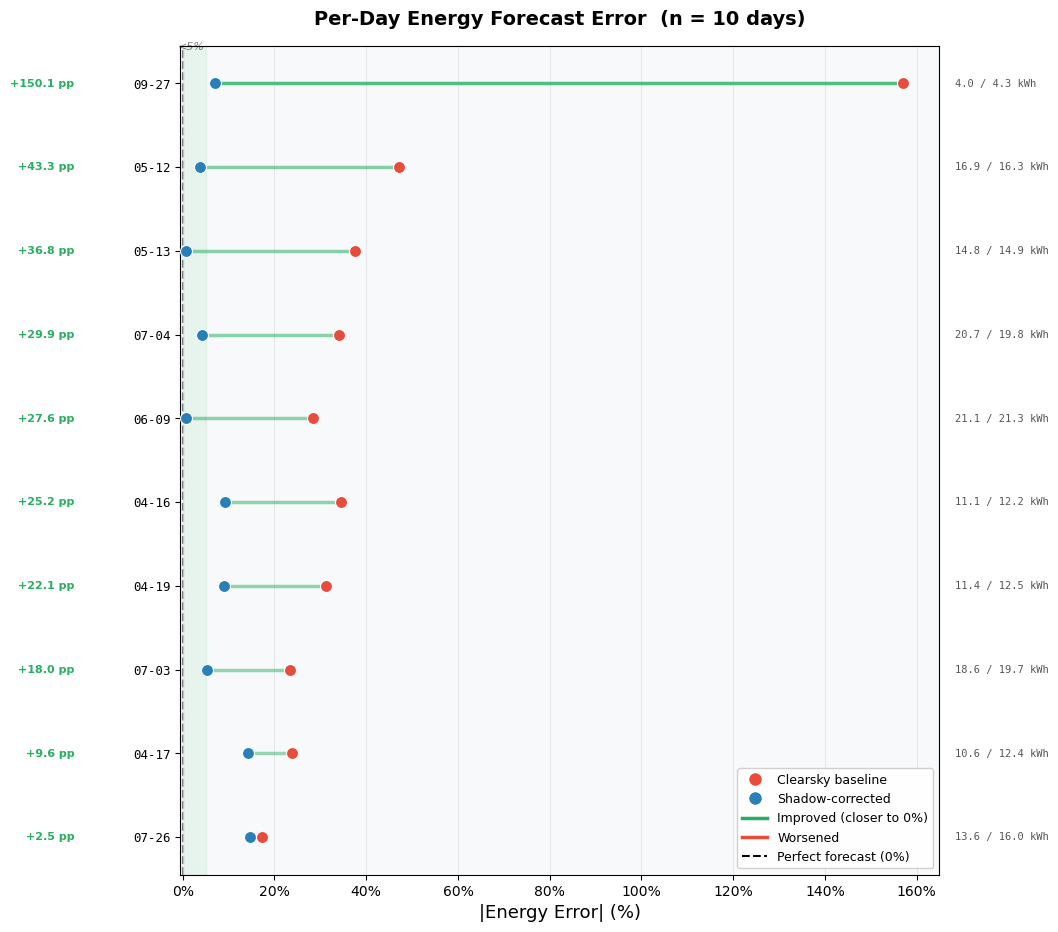

Saved: results/plots_b2/energy_slope_pct_b2.png


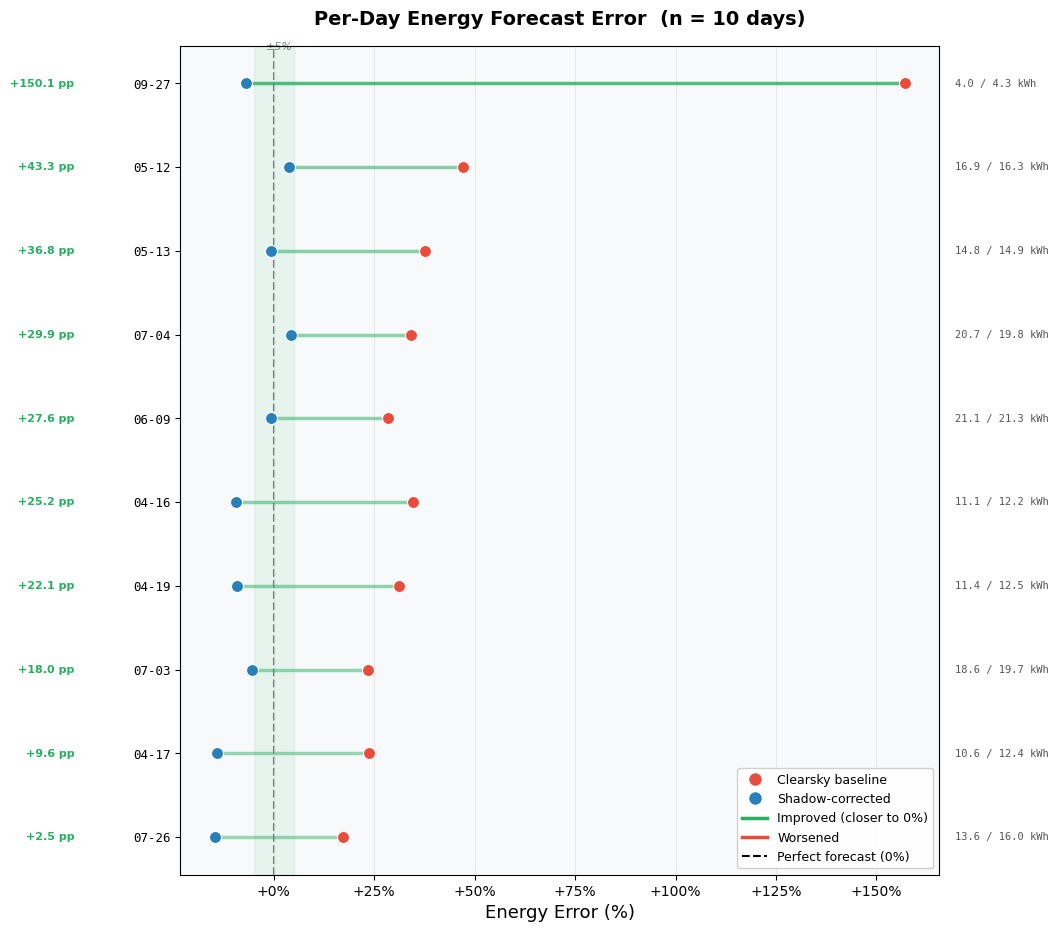

In [19]:
from plot_daily_distributions import (
    plot_raincloud, plot_paired_slope, plot_ridgeline, plot_energy_slope
)
# _ = plot_raincloud(results_df, save_path="results/plots_b1/raincloud_b1.png", figsize=(10, 10))
_ = plot_paired_slope(results_df, save_path="results/plots_b2/slope_b2.png")
_ = plot_ridgeline(results_df, save_path=str(MANUSCRIPT_FIG_DIR / "b2_clearsky_ridgeline.png"), dpi=300, figsize=(13, 10.5))
_ = plot_energy_slope(results_df, use_absolute=True, save_path="results/plots_b2/energy_slope_b2.png")
_ = plot_energy_slope(results_df, use_absolute=False, save_path="results/plots_b2/energy_slope_pct_b2.png")

Evaluating 153 days: 2021-05-01 → 2021-09-30


All days: 100%|██████████| 153/153 [00:04<00:00, 34.96it/s]


Per-day results saved to: all_days_metrics_bank2.csv

  OVERALL METRICS — 2021-05-01 to 2021-09-30
  153 days evaluated, 0 skipped, 27396 daytime samples

  Metric                   Baseline  Shadow-Corr  Improvement
  --------------------------------------------------------
  RMSE (W)                    636.4        470.8        26.0%
  MAE (W)                     413.2        286.8        30.6%
  MBE (W)                     261.5        -45.5       closer
  R²                          0.295        0.614       +0.319

  Energy (kWh)             Real       Base  Corrected
  ------------------------------------------------
  Total                  1737.5     2341.2     1637.3
  Error                             +34.7%      -5.8%

  Per-day averages (mean of 153 daily metrics):
  RMSE      Base: 585.4 ± 230.7   Corr: 426.7 ± 178.3
  MAE       Base: 403.7 ± 168.8   Corr: 279.4 ± 106.9
  MBE       Base: 255.1 ± 174.4   Corr: -49.9 ± 97.7
  R²        Base: -0.218 ± 1.134   Corr: 0.385 ± 0.3

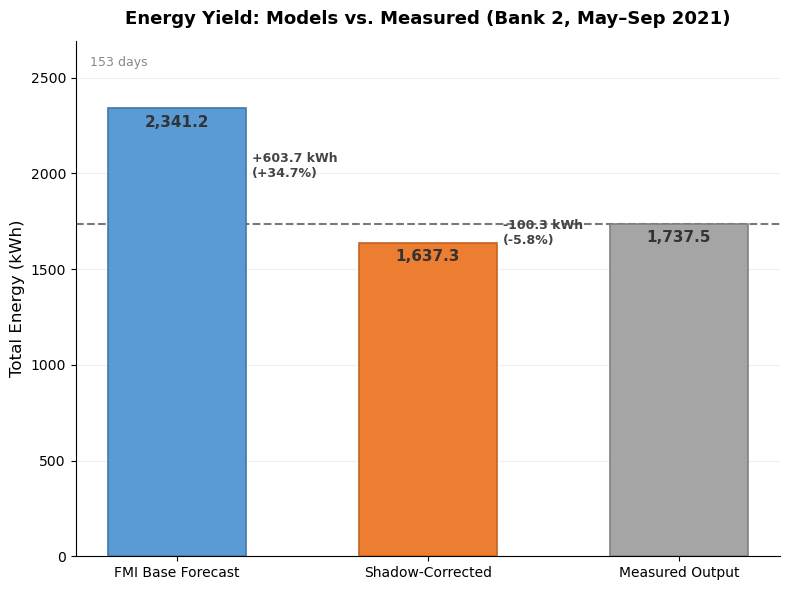

Saved: /Users/hdong/Projects/VoxSolaris_Article/figs/b2_fullperiod_rmse.png


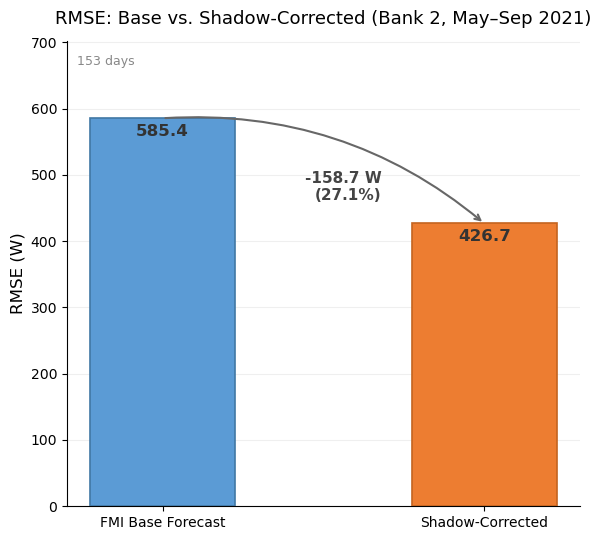

In [20]:
# %% --- 13. Evaluate ALL days May–September (Bank 2) ---
from evaluate_all_days import evaluate_all_days, plot_energy_bar_chart, _plot_metric_comparison

def _bank2_pv_analysis_wrapper(date_obj, shadow_matrix, excel_df, df_extra, cfg, plot=False):
    """Wrapper so evaluate_all_days can call Bank 2's dual-matrix analysis."""
    return pv_analysis_bank2(
        date_obj, shadow_north, shadow_south,
        excel_df, df_extra, plot=False,
    )

# Monkey-patch pv_analysis in evaluate_all_days for Bank 2
import evaluate_all_days as _ead
_original_pv = None
try:
    import pv_analysis_b2 as _pva
    _original_pv = _pva.pv_analysis
    _pva.pv_analysis = _bank2_pv_analysis_wrapper

    all_results_b2, all_real_b2, all_base_b2, all_shad_b2 = evaluate_all_days(
        start_date="2021-05-01",
        end_date="2021-09-30",
        shadow_matrix=shadow_north,  # placeholder, wrapper ignores it
        excel_df=pv_df,
        extra_data_loader=extra_loader,
        cfg=cfg_combined,
        output_csv="all_days_metrics_bank2.csv",
    )

    plot_energy_bar_chart(
        all_results_b2,
        title_suffix="Bank 2, May–Sep 2021",
        save_path=str(MANUSCRIPT_FIG_DIR / "b2_fullperiod_energy.png"),
    )
    _plot_metric_comparison(
        all_results_b2["RMSE_Base"].mean(),
        all_results_b2["RMSE_Shaded"].mean(),
        "RMSE",
        "W",
        n_days=len(all_results_b2),
        title_suffix="Bank 2, May–Sep 2021",
        save_path=str(MANUSCRIPT_FIG_DIR / "b2_fullperiod_rmse.png"),
    )
finally:
    if _original_pv is not None:
        _pva.pv_analysis = _original_pv